In [3]:
!pip install pydicom
!pip install scipy
!pip install nibabel

In [4]:
import os
import torch
import pydicom
import numpy as np
import pandas as pd

from scipy.ndimage import zoom

In [5]:
data = pd.read_csv("/kaggle/input/datasets/ramcharanreddy508/clinical-genomic-data/trimodal_clinical_genomic_dataset.csv")

print(data.shape)
data.head()

(1111, 15)


,Patient_ID,Overall_Survival_Days,Event,age,gender,Tumor_Type,race_black or african american,race_other,race_white,ATRX,EGFR,IDH1,NF1,PTEN,TP53
0,TCGA-14-1034,485.0,1,0.575278,0,1,0,1,0,0.0,1.0,0.0,1.0,1.0,1.0
1,TCGA-06-0133,435.0,1,0.828902,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
2,TCGA-06-0140,6.0,1,2.223837,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
3,TCGA-06-0171,399.0,1,0.892308,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
4,TCGA-06-0402,8.0,1,1.272745,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_dir = "/kaggle/input/competitions/rsna-miccai-brain-tumor-radiogenomic-classification/train"

train_ids = sorted(os.listdir(train_dir))

rsna_ids = train_ids

print("MRI patients:", len(rsna_ids))

MRI patients: 585


In [7]:
data = data.iloc[:len(rsna_ids)].copy()

data["BraTS21ID"] = rsna_ids

data.head()

,Patient_ID,Overall_Survival_Days,Event,age,gender,Tumor_Type,race_black or african american,race_other,race_white,ATRX,EGFR,IDH1,NF1,PTEN,TP53,BraTS21ID
0,TCGA-14-1034,485.0,1,0.575278,0,1,0,1,0,0.0,1.0,0.0,1.0,1.0,1.0,00000
1,TCGA-06-0133,435.0,1,0.828902,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,00002
2,TCGA-06-0140,6.0,1,2.223837,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,00003
3,TCGA-06-0171,399.0,1,0.892308,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,00005
4,TCGA-06-0402,8.0,1,1.272745,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,00006


In [8]:
def resize_volume(volume,target=(64,128,128)):

    factors = (
        target[0]/volume.shape[0],
        target[1]/volume.shape[1],
        target[2]/volume.shape[2]
    )

    volume = zoom(volume,factors)

    return volume

In [9]:
def load_series(folder):

    slices = []

    for f in sorted(os.listdir(folder)):

        try:
            path = os.path.join(folder,f)
            dcm = pydicom.dcmread(path)
            slices.append(dcm.pixel_array)

        except:
            continue

    if len(slices)==0:
        return None

    return np.stack(slices)

In [15]:
def load_patient(pid):

    train_base = f"{train_dir}/{pid}"

    if os.path.exists(train_base):
        base = train_base

    flair = load_series(base+"/FLAIR")
    t1 = load_series(base+"/T1w")
    t1ce = load_series(base+"/T1wCE")
    t2 = load_series(base+"/T2w")

    if flair is None or t1 is None or t1ce is None or t2 is None:
        return None

    flair = resize_volume(flair)
    t1 = resize_volume(t1)
    t1ce = resize_volume(t1ce)
    t2 = resize_volume(t2)

    volume = np.stack([flair,t1,t1ce,t2])

    return volume

In [11]:
!git clone https://github.com/Tencent/MedicalNet.git

Cloning into 'MedicalNet'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 129 (delta 54), reused 44 (delta 44), pack-reused 56 (from 2)
Receiving objects: 100% (129/129), 47.64 MiB | 46.72 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [12]:
from MedicalNet.models import resnet

model = resnet.resnet18(
    sample_input_D=64,
    sample_input_H=128,
    sample_input_W=128,
    shortcut_type='A',
    no_cuda=False,
    num_seg_classes=1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

/kaggle/working/MedicalNet/models/resnet.py:173: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [16]:
features = []
ids = []

for i, pid in enumerate(data["BraTS21ID"]):

    if i % 10 == 0:
        print("Processing", i)

    mri = load_patient(pid)

    if mri is None:
        continue

    mri = np.mean(mri, axis=0)

    tensor = torch.tensor(mri).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():

        feat = model(tensor)

        feat = torch.mean(feat, dim=[2,3,4])   # global average pooling

    features.append(feat.cpu().numpy().flatten())
    ids.append(data.iloc[i]["Patient_ID"])

    del tensor
    torch.cuda.empty_cache()

Processing 0
Processing 10


KeyboardInterrupt: 

In [ ]:
mri_features = pd.DataFrame(features)

mri_features["Patient_ID"] = ids

print(mri_features.shape)

mri_features.to_csv("medicalnet_mri_features.csv",index=False)

In [24]:
import pandas as pd
import numpy as np

mri = pd.read_csv("/kaggle/input/datasets/ramcharanreddy508/medicalnet-mri-features/medicalnet_mri_features.csv")

print(mri.shape)

(585, 16385)


In [2]:
ids = mri["Patient_ID"]

X = mri.drop(columns=["Patient_ID"]).values

In [3]:
X = X.reshape(len(X),512,2,4,4)

X = X.mean(axis=(2,3,4))

In [4]:
mri_512 = pd.DataFrame(X)

mri_512["Patient_ID"] = ids

print(mri_512.shape)

mri_512.to_csv("mri_features_512.csv",index=False)

(585, 513)


In [2]:
!pip install scikit-survival --quiet
!pip install lifelines --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 43.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv

from lifelines.utils import concordance_index

In [4]:
import pandas as pd

clinical_genomic = pd.read_csv("/kaggle/input/datasets/ramcharanreddy508/clinical-genomic-data/trimodal_clinical_genomic_dataset.csv")

mri_features = pd.read_csv("/kaggle/input/datasets/ramcharanreddy508/mri-features-512/mri_features_512.csv")

print(clinical_genomic.shape)
print(mri_features.shape)

clinical_genomic.head()

(1111, 15)
(585, 513)


,Patient_ID,Overall_Survival_Days,Event,age,gender,Tumor_Type,race_black or african american,race_other,race_white,ATRX,EGFR,IDH1,NF1,PTEN,TP53
0,TCGA-14-1034,485.0,1,0.575278,0,1,0,1,0,0.0,1.0,0.0,1.0,1.0,1.0
1,TCGA-06-0133,435.0,1,0.828902,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
2,TCGA-06-0140,6.0,1,2.223837,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
3,TCGA-06-0171,399.0,1,0.892308,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
4,TCGA-06-0402,8.0,1,1.272745,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
data = clinical_genomic.merge(
    mri_features,
    on="Patient_ID",
    how="inner"
)

print(data.shape)
data.head()

(585, 527)


,Patient_ID,Overall_Survival_Days,Event,age,gender,Tumor_Type,race_black or african american,race_other,race_white,ATRX,...,502,503,504,505,506,507,508,509,510,511
0,TCGA-14-1034,485.0,1,0.575278,0,1,0,1,0,0.0,...,328.791147,19.147883,327.889349,26.729018,299.939877,53.661675,245.524362,83.002365,204.057323,126.460030
1,TCGA-06-0133,435.0,1,0.828902,1,1,0,0,1,0.0,...,254.383039,-2.007384,282.745243,28.183381,282.398777,11.104598,217.142061,60.375011,188.878366,110.329008
2,TCGA-06-0140,6.0,1,2.223837,1,1,0,0,1,0.0,...,307.198288,-4.079883,293.787452,29.733875,279.488117,66.030393,247.634259,82.506336,194.378908,127.915106
3,TCGA-06-0171,399.0,1,0.892308,1,1,0,0,1,0.0,...,327.399331,5.718946,354.224530,49.958874,340.600274,35.274293,270.057826,60.510950,217.173462,126.985462
4,TCGA-06-0402,8.0,1,1.272745,1,1,0,0,1,0.0,...,381.289515,-23.696098,377.012994,39.033392,374.069593,50.395934,321.517498,62.039399,268.813866,152.257562


In [6]:
time = data["Overall_Survival_Days"].values
event = data["Event"].values

In [7]:
mri_cols = [str(i) for i in range(512)]

X_mri = data[mri_cols].values

In [8]:
clinical_cols = [
    "age",
    "gender",
    "Tumor_Type",
    "race_black or african american",
    "race_other",
    "race_white"
]

X_clinical = data[clinical_cols].values

In [9]:
genomic_cols = [
    "IDH1",
    "TP53",
    "ATRX",
    "PTEN",
    "EGFR",
    "NF1"
]

X_genomic = data[genomic_cols].values

In [10]:
print(X_mri.shape)
print(X_clinical.shape)
print(X_genomic.shape)

(585, 512)
(585, 6)
(585, 6)


In [11]:
pca = PCA(n_components=30)

X_mri = pca.fit_transform(X_mri)

print("New MRI feature size:", X_mri.shape)

New MRI feature size: (585, 30)


In [12]:
pca.explained_variance_ratio_.sum()

np.float64(0.9933768961496837)

In [13]:
from sksurv.util import Surv

y = Surv.from_arrays(event.astype(bool), time)

In [14]:
def evaluate_model(X):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for train_idx, val_idx in kf.split(X):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = CoxnetSurvivalAnalysis(l1_ratio=0.5)

        model.fit(X_train, y_train)

        risk = model.predict(X_val)

        c = concordance_index(time[val_idx], -risk, event[val_idx])

        scores.append(c)

    return np.mean(scores)

In [15]:
from sksurv.linear_model import CoxnetSurvivalAnalysis

mri_model = CoxnetSurvivalAnalysis(l1_ratio=0.5)
clinical_model = CoxnetSurvivalAnalysis(l1_ratio=0.5)
genomic_model = CoxnetSurvivalAnalysis(l1_ratio=0.5)

mri_model.fit(X_mri, y)
clinical_model.fit(X_clinical, y)
genomic_model.fit(X_genomic, y)

CoxnetSurvivalAnalysis()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.linear_model import CoxnetSurvivalAnalysis

# combine clinical + genomic features
X_cli_gen = np.hstack([X_clinical, X_genomic])

feature_names = clinical_cols + genomic_cols

# train model
importance_model = CoxnetSurvivalAnalysis(l1_ratio=0.5)
importance_model.fit(X_cli_gen, y)

# Coxnet returns multiple coefficient sets
coef = importance_model.coef_[:, -1]   # take final model

# build dataframe
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance["abs_coef"] = np.abs(importance["Coefficient"])
importance = importance.sort_values("abs_coef", ascending=False)

print(importance)

                           Feature  Coefficient  abs_coef
4                       race_other     0.711808  0.711808
0                              age     0.547065  0.547065
5                       race_white     0.440357  0.440357
7                             TP53    -0.398637  0.398637
6                             IDH1    -0.376677  0.376677
3   race_black or african american     0.314904  0.314904
1                           gender     0.175891  0.175891
8                             ATRX     0.171985  0.171985
10                            EGFR    -0.157925  0.157925
9                             PTEN    -0.055815  0.055815
2                       Tumor_Type     0.000000  0.000000
11                             NF1     0.000000  0.000000


In [17]:
import joblib

joblib.dump(clinical_model, "clinical_model.pkl")
joblib.dump(genomic_model, "genomic_model.pkl")

['genomic_model.pkl']

In [18]:
mri_risk = mri_model.predict(X_mri)
clinical_risk = clinical_model.predict(X_clinical)
genomic_risk = genomic_model.predict(X_genomic)

In [19]:
mri_risk = mri_risk * 0.5
clinical_risk = clinical_risk * 2
genomic_risk = genomic_risk * 1.5

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

risk_stack = np.vstack([mri_risk, clinical_risk, genomic_risk]).T
risk_stack = scaler.fit_transform(risk_stack)

X_fusion = risk_stack

In [21]:
X_cli_geo = np.vstack([clinical_risk,genomic_risk]).T
print(X_cli_geo.shape)

X_cli_mri = np.vstack([clinical_risk,mri_risk]).T
print(X_cli_mri.shape)

X_mri_geo = np.vstack([mri_risk,genomic_risk]).T
print(X_cli_geo.shape)

(585, 2)
(585, 2)
(585, 2)


In [22]:
score = evaluate_model(X_fusion)

print("Late Fusion Trimodal C-index:", score)

Late Fusion Trimodal C-index: 0.6694972068122211


In [24]:
results = {}

results["MRI Only"] = evaluate_model(X_mri)
results["Clinical Only"] = evaluate_model(X_clinical)
results["Genomic Only"] = evaluate_model(X_genomic)

results["Cinical & Genomic"] = evaluate_model(X_cli_geo)
results["Clinical & MRI"] = evaluate_model(X_cli_mri)
results["MRI & Genomic"] = evaluate_model(X_mri_geo)



results["Trimodal"] = evaluate_model(X_fusion)

print(results)

{'MRI Only': np.float64(0.524993770556436), 'Clinical Only': np.float64(0.6519668498039255), 'Genomic Only': np.float64(0.5332482000648798), 'Cinical & Genomic': np.float64(0.6651835970573108), 'Clinical & MRI': np.float64(0.6631975127343506), 'MRI & Genomic': np.float64(0.5871450039762699), 'Trimodal': np.float64(0.6694972068122211)}


In [25]:
joblib.dump(scaler, "fusion_scaler.pkl")

['fusion_scaler.pkl']

In [26]:
feature_cols = clinical_cols + genomic_cols

joblib.dump(feature_cols, "feature_order.pkl")

['feature_order.pkl']

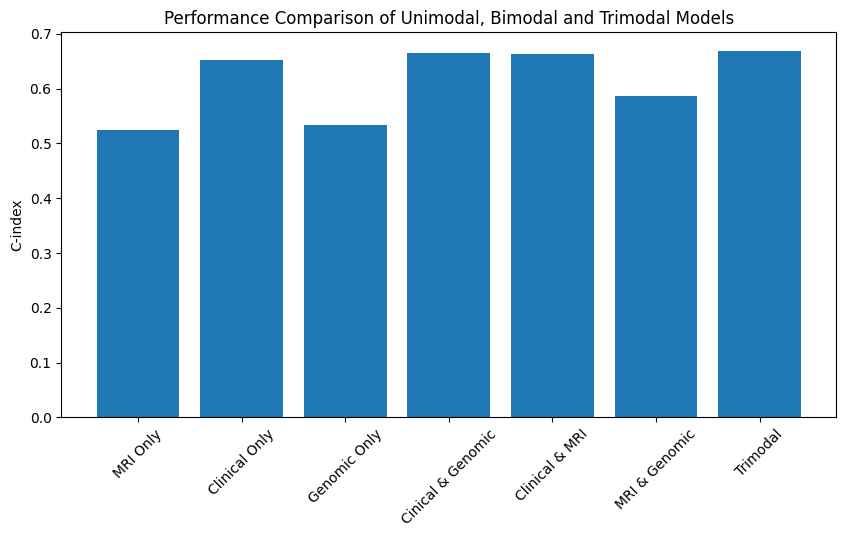

In [27]:
import matplotlib.pyplot as plt

models = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(10,5))
plt.bar(models, scores)
plt.ylabel("C-index")
plt.xticks(rotation=45)
plt.title("Performance Comparison of Unimodal, Bimodal and Trimodal Models")
plt.show()

In [39]:
import numpy as np

order = np.argsort(risk_scores)

risk_sorted = risk_scores[order]
time_sorted = time[order]
event_sorted = event[order]

Log-rank p-value: 3.931951524437142e-15


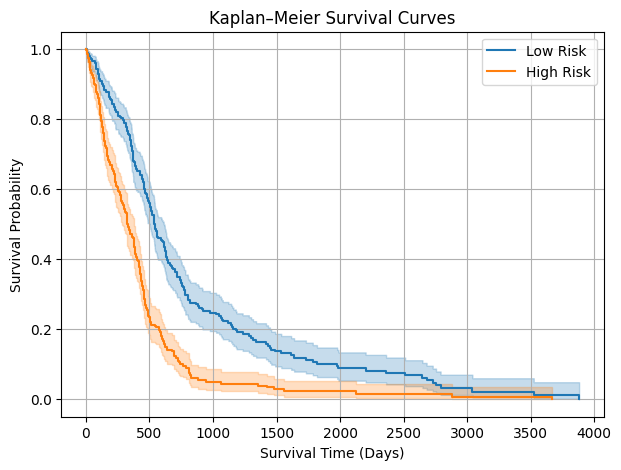

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# convert to arrays
risk = np.array(risk_scores)
time = np.array(time)
event = np.array(event)

# split high vs low risk
median_risk = np.median(risk)

high_risk = risk >= median_risk
low_risk = risk < median_risk

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

kmf.fit(time[low_risk], event[low_risk], label="Low Risk")
ax = kmf.plot()

kmf.fit(time[high_risk], event[high_risk], label="High Risk")
kmf.plot(ax=ax)

plt.title("Kaplan–Meier Survival Curves")
plt.xlabel("Survival Time (Days)")
plt.ylabel("Survival Probability")
plt.grid(True)

# log-rank test
results = logrank_test(
    time[low_risk],
    time[high_risk],
    event[low_risk],
    event[high_risk]
)

print("Log-rank p-value:", results.p_value)

plt.show()

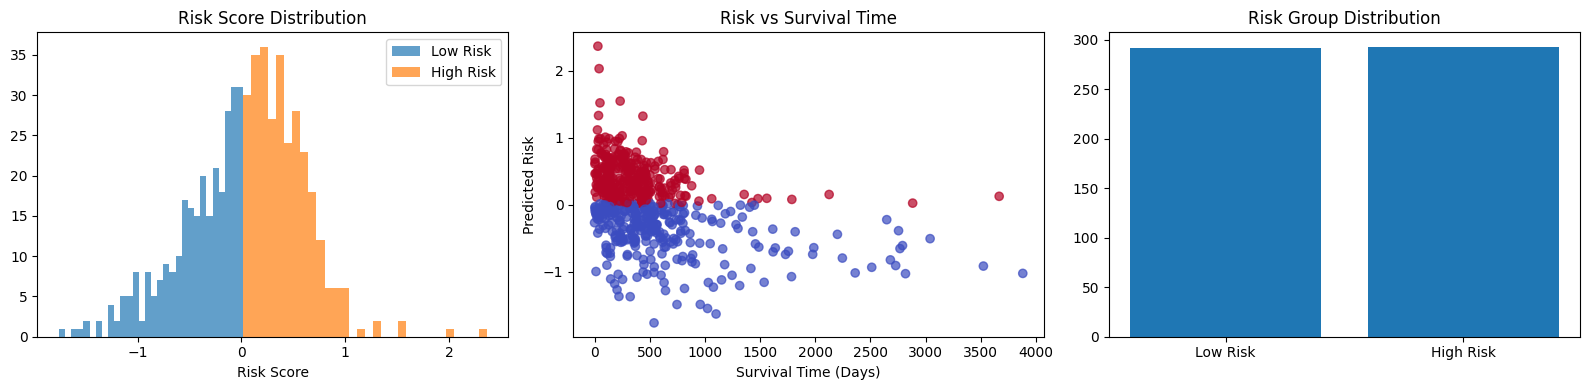

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(16,4))

# Panel A: Risk histogram
axes[0].hist(risk[low_risk], bins=30, alpha=0.7, label="Low Risk")
axes[0].hist(risk[high_risk], bins=30, alpha=0.7, label="High Risk")
axes[0].set_title("Risk Score Distribution")
axes[0].set_xlabel("Risk Score")
axes[0].legend()

# Panel B: Survival scatter
axes[1].scatter(time, risk, c=high_risk, cmap="coolwarm", alpha=0.7)
axes[1].set_title("Risk vs Survival Time")
axes[1].set_xlabel("Survival Time (Days)")
axes[1].set_ylabel("Predicted Risk")

# Panel C: Group count
axes[2].bar(["Low Risk","High Risk"], 
            [sum(low_risk), sum(high_risk)])
axes[2].set_title("Risk Group Distribution")

plt.tight_layout()
plt.show()

AUC at 365 days: 0.7127567404644011
AUC at 730 days: 0.764101898414628
AUC at 1095 days: 0.8107052352421626


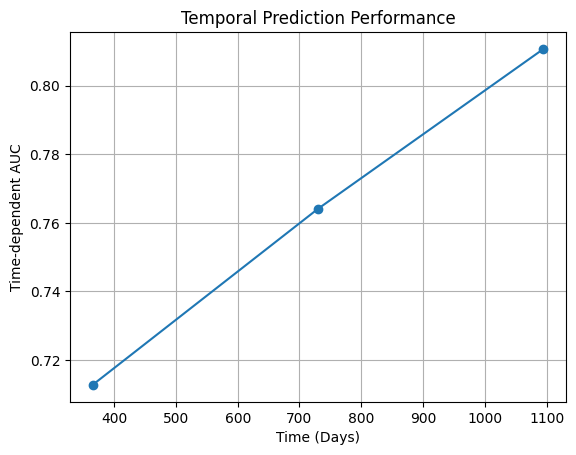

In [52]:
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

y = Surv.from_arrays(event.astype(bool), time)

times = np.array([365, 730, 1095])

auc, mean_auc = cumulative_dynamic_auc(
    y,
    y,
    risk,
    times
)

for t,a in zip(times, auc):
    print(f"AUC at {int(t)} days:", a)

plt.plot(times, auc, marker="o")
plt.xlabel("Time (Days)")
plt.ylabel("Time-dependent AUC")
plt.title("Temporal Prediction Performance")
plt.grid()
plt.show()

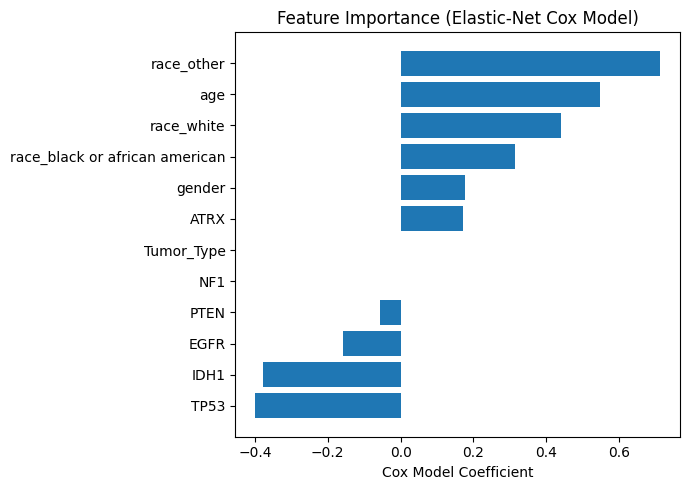

In [54]:
importance = importance.sort_values("Coefficient")

plt.figure(figsize=(7,5))

plt.barh(importance["Feature"], importance["Coefficient"])

plt.xlabel("Cox Model Coefficient")
plt.title("Feature Importance (Elastic-Net Cox Model)")

plt.tight_layout()
plt.show()

In [47]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

# median split
median_risk = np.median(risk_scores)

risk_group = (risk_scores >= median_risk).astype(int)

df_hr = pd.DataFrame({
    "time": time,
    "event": event,
    "risk_group": risk_group
})

# fix zero survival times
df_hr["time"] = np.where(df_hr["time"] <= 0, 1, df_hr["time"])

cph = CoxPHFitter()
cph.fit(df_hr, duration_col="time", event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 585 total observations, 104 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 585
number of events observed = 481
   partial log-likelihood = -2552.06
         time fit was run = 2026-03-10 12:08:34 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
risk_group  0.73      2.07      0.09            0.54            0.91                1.72                2.49

            cmp to    z      p  -log2(p)
covariate                               
risk_group    0.00 7.71 <0.005     46.20
---
Concordance = 0.60
Partial AIC = 5106.12
log-likelihood ratio test = 59.08 on 1 df
-log2(p) of ll-ratio test = 45.91

In [49]:
from lifelines import CoxPHFitter

df_cal = pd.DataFrame({
    "time": time,
    "event": event,
    "risk": risk_scores
})

df_cal["time"] = np.where(df_cal["time"] <= 0, 1, df_cal["time"])

cph = CoxPHFitter()
cph.fit(df_cal, duration_col="time", event_col="event")

print("Calibration slope:", cph.params_)

Calibration slope: covariate
risk    1.148771
Name: coef, dtype: float64


AUC at 365 days: 0.7127567404644011
AUC at 730 days: 0.764101898414628
AUC at 1095 days: 0.8107052352421626


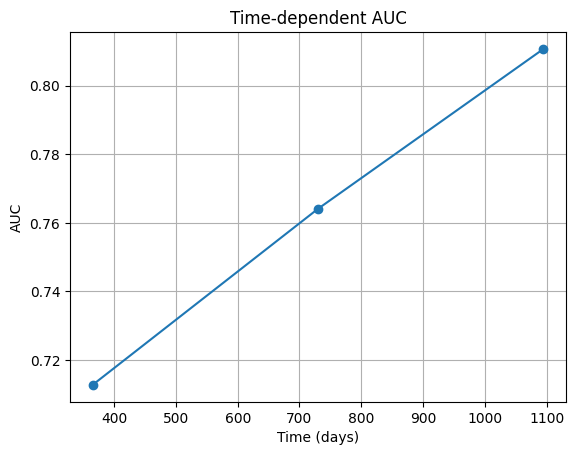

In [50]:
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv
import numpy as np
import matplotlib.pyplot as plt

y = Surv.from_arrays(event.astype(bool), time)

# evaluation times
times = np.array([365, 730, 1095])

auc, mean_auc = cumulative_dynamic_auc(
    y,
    y,
    risk_scores,
    times
)

for t,a in zip(times, auc):
    print(f"AUC at {t} days:", a)

plt.plot(times, auc, marker="o")
plt.xlabel("Time (days)")
plt.ylabel("AUC")
plt.title("Time-dependent AUC")
plt.grid()
plt.show()

In [53]:
import pandas as pd
import numpy as np

median_risk = np.median(risk_scores)

low = risk_scores[risk_scores < median_risk]
high = risk_scores[risk_scores >= median_risk]

print("Low risk count:", len(low))
print("High risk count:", len(high))

print("Low risk mean ± SD:",
      np.mean(low), "±", np.std(low))

print("High risk mean ± SD:",
      np.mean(high), "±", np.std(high))

print("Low risk %:", len(low)/len(risk_scores)*100)
print("High risk %:", len(high)/len(risk_scores)*100)

Low risk count: 292
High risk count: 293
Low risk mean ± SD: -0.4246024696784341 ± 0.36680753967866186
High risk mean ± SD: 0.4231533144918187 ± 0.3112317416314848
Low risk %: 49.914529914529915
High risk %: 50.085470085470085
